#  Task 6: Question Answering with Transformers

**Goal:** Build a system that extracts answers from a passage given a question  
**Dataset:** SQuAD v1.1 (Stanford Question Answering Dataset — Hugging Face)  
**Topics:** Question Answering | Span Extraction | Transformer-based NLP  

---
### Pipeline
```
Load SQuAD ->> Explore Data -> Load Pre-trained Models -> Run QA → Evaluate (EM + F1) -> Compare Models -> and maybe Bonus: Streamlit UI
```

## Step 1: Install & Import Libraries

In [ ]:
!pip install transformers datasets pandas numpy matplotlib seaborn torch --quiet

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import string
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from datasets import load_dataset
from transformers import pipeline

plt.style.use('seaborn-v0_8-whitegrid')
print(' Libraries ready!')

 Libraries ready!


---
## Step 2: Load SQuAD v1.1 Dataset

In [3]:
print('Loading SQuAD v1.1 from Hugging Face...')
squad = load_dataset('squad')

print(f'Train examples : {len(squad["train"]):,}')
print(f'Val   examples : {len(squad["validation"]):,}')

# Convert validation split to DataFrame for easy manipulation
df = pd.DataFrame(squad['validation'])

# Flatten the answers column — SQuAD stores answers as dict with list of texts
df['answer_text']  = df['answers'].apply(lambda x: x['text'][0] if x['text'] else '')
df['answer_start'] = df['answers'].apply(lambda x: x['answer_start'][0] if x['answer_start'] else 0)

print(f'\nColumns: {list(df.columns)}')


Loading SQuAD v1.1 from Hugging Face...
Train examples : 87,599
Val   examples : 10,570

Columns: ['id', 'title', 'context', 'question', 'answers', 'answer_text', 'answer_start']


In [4]:
df[['title', 'question', 'context', 'answer_text']].head(5)

,title,question,context,answer_text
0,Super_Bowl_50,Which NFL team represented the AFC at Super Bo...,Super Bowl 50 was an American football game to...,Denver Broncos
1,Super_Bowl_50,Which NFL team represented the NFC at Super Bo...,Super Bowl 50 was an American football game to...,Carolina Panthers
2,Super_Bowl_50,Where did Super Bowl 50 take place?,Super Bowl 50 was an American football game to...,"Santa Clara, California"
3,Super_Bowl_50,Which NFL team won Super Bowl 50?,Super Bowl 50 was an American football game to...,Denver Broncos
4,Super_Bowl_50,What color was used to emphasize the 50th anni...,Super Bowl 50 was an American football game to...,gold


---
## Step 3: Exploratory Data Analysis

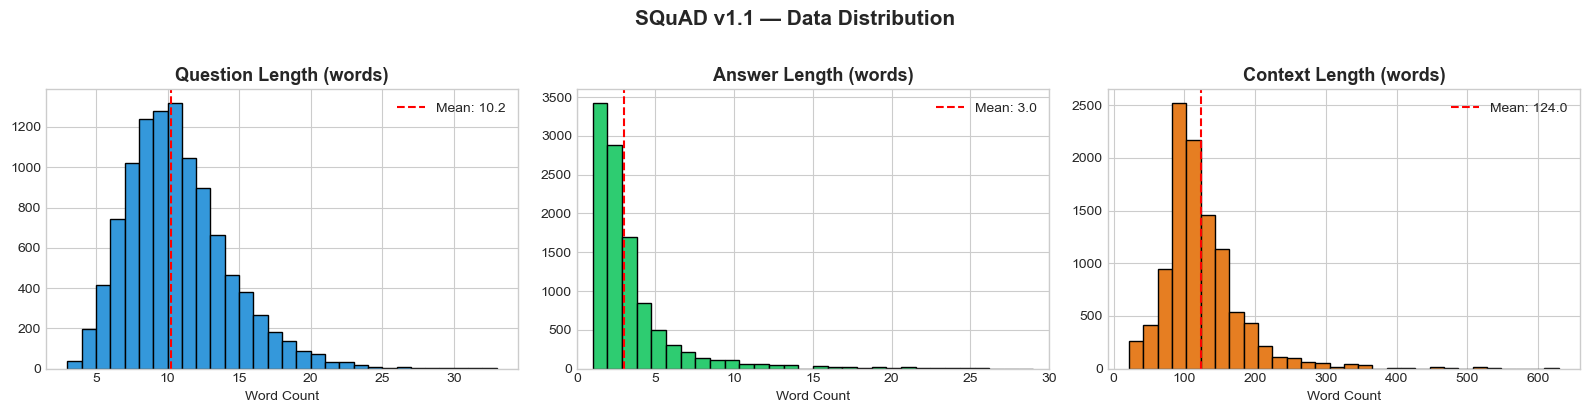

Unique articles  : 48
Total QA pairs   : 10,570


In [5]:
df['question_len'] = df['question'].apply(lambda x: len(x.split()))
df['answer_len']   = df['answer_text'].apply(lambda x: len(x.split()))
df['context_len']  = df['context'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['question_len'], bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Question Length (words)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].axvline(df['question_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["question_len"].mean():.1f}')
axes[0].legend()

axes[1].hist(df['answer_len'], bins=30, color='#2ecc71', edgecolor='black')
axes[1].set_title('Answer Length (words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].axvline(df['answer_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["answer_len"].mean():.1f}')
axes[1].legend()
axes[1].set_xlim(0, 30)

axes[2].hist(df['context_len'], bins=30, color='#e67e22', edgecolor='black')
axes[2].set_title('Context Length (words)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].axvline(df['context_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["context_len"].mean():.1f}')
axes[2].legend()

plt.suptitle('SQuAD v1.1 — Data Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unique articles  : {df["title"].nunique()}')
print(f'Total QA pairs   : {len(df):,}')

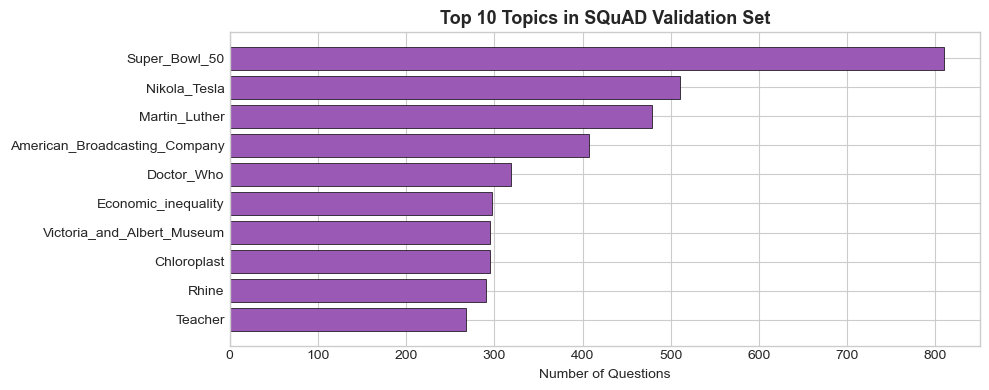

In [6]:
# Top 10 topics in the dataset
top_titles = df['title'].value_counts().head(10)

plt.figure(figsize=(10, 4))
plt.barh(list(reversed(top_titles.index)), list(reversed(top_titles.values)),
         color='#9b59b6', edgecolor='black', linewidth=0.5)
plt.title('Top 10 Topics in SQuAD Validation Set', fontsize=13, fontweight='bold')
plt.xlabel('Number of Questions')
plt.tight_layout()
plt.savefig('top_topics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4: Load Pre-trained QA Models

We use the Hugging Face `pipeline` for span-extraction QA.  
Models are already **fine-tuned on SQuAD** — no training needed.

| Model | Size | Notes |
|---|---|---|
| `distilbert-base-cased-distilled-squad` | ~250MB | Fast, lightweight |
| `deepset/roberta-base-squad2` | ~500MB | More accurate |
| `deepset/bert-base-cased-squad2` | ~420MB | Classic BERT |

In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}\n')

MODEL_NAMES = {
    'DistilBERT': 'distilbert-base-cased-distilled-squad',
    'RoBERTa'   : 'deepset/roberta-base-squad2',
    'BERT'      : 'deepset/bert-base-cased-squad2'
}

tokenizers = {}
models_map = {}

for name, model_id in MODEL_NAMES.items():
    print(f'Loading {name} ({model_id})...')
    tokenizers[name] = AutoTokenizer.from_pretrained(model_id)
    models_map[name] = AutoModelForQuestionAnswering.from_pretrained(model_id).to(DEVICE)
    models_map[name].eval()
    print(f'   {name} ready!')


def answer_question(question, context, model_name):
    """
    Extract an answer span from context given a question.

    How it works:
    1. Tokenize question + context together as a single input
    2. Model outputs start/end logits — a score for each token
       being the start or end of the answer
    3. We pick the token positions with the highest scores
    4. Decode those tokens back to text = the answer
    """
    tokenizer = tokenizers[model_name]
    model     = models_map[model_name]

    # Tokenize — question and context are separated by [SEP] token internally
    inputs = tokenizer(
        question,
        context,
        return_tensors='pt',
        max_length=512,
        truncation=True,
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    # Get the most likely start and end token positions
    start_idx = torch.argmax(outputs.start_logits)
    end_idx   = torch.argmax(outputs.end_logits) + 1  # +1 because end is exclusive

    # Convert token IDs back to a string
    answer_tokens = inputs['input_ids'][0][start_idx:end_idx]
    answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)

    # Confidence score = softmax of start * end logit
    start_score = torch.softmax(outputs.start_logits, dim=1)[0][start_idx].item()
    end_score   = torch.softmax(outputs.end_logits,   dim=1)[0][end_idx-1].item()
    confidence  = round((start_score + end_score) / 2, 4)

    return {'answer': answer, 'score': confidence}


print('\n All models loaded and answer_question() ready!')

Using device: cpu

Loading DistilBERT (distilbert-base-cased-distilled-squad)...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: deepset/bert-base-cased-squad2
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   BERT ready!

 All models loaded and answer_question() ready!


---
## Step 5: Run Question Answering — Quick Demo

In [14]:
demo_examples = [
    {
        'context' : 'The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. '
                    'It was constructed from 1887 to 1889 as the centerpiece of the 1889 World\'s Fair. '
                    'The tower is 330 metres tall and is the tallest structure in Paris.',
        'question': 'How tall is the Eiffel Tower?'
    },
    {
        'context' : 'Albert Einstein was born on March 14, 1879, in Ulm, in the Kingdom of Württemberg. '
                    'He developed the theory of relativity and received the Nobel Prize in Physics in 1921 '
                    'for his discovery of the law of the photoelectric effect.',
        'question': 'When was Albert Einstein born?'
    },
    {
        'context' : 'Python is a high-level, general-purpose programming language. Its design philosophy '
                    'emphasizes code readability with the use of significant indentation. Python was '
                    'created by Guido van Rossum and first released in 1991.',
        'question': 'Who created Python?'
    }
]

print('=== Demo QA Results ===\n')
for i, example in enumerate(demo_examples, 1):
    print(f'Q{i}: {example["question"]}')
    for model_name in MODEL_NAMES:
        result = answer_question(example['question'], example['context'], model_name)
        print(f'  [{model_name:<10}]  Answer: "{result["answer"]}"  (score: {result["score"]})')
    print()

=== Demo QA Results ===

Q1: How tall is the Eiffel Tower?
  [DistilBERT]  Answer: "330 metres"  (score: 0.7819)
  [RoBERTa   ]  Answer: " 330 metres"  (score: 0.7691)
  [BERT      ]  Answer: "330 metres tall"  (score: 0.7569)

Q2: When was Albert Einstein born?
  [DistilBERT]  Answer: "March 14, 1879"  (score: 0.9914)
  [RoBERTa   ]  Answer: " March 14, 1879"  (score: 0.9828)
  [BERT      ]  Answer: "March 14, 1879"  (score: 0.9941)

Q3: Who created Python?
  [DistilBERT]  Answer: "Guido van Rossum"  (score: 0.9985)
  [RoBERTa   ]  Answer: " Guido van Rossum"  (score: 0.9952)
  [BERT      ]  Answer: "Guido van Rossum"  (score: 0.9998)



---
## Step 6: Evaluate on SQuAD — Exact Match & F1 Score

**Exact Match (EM):** 1 if predicted answer exactly equals ground truth (after normalization)  
**F1 Score:** Token-level overlap between predicted and ground truth answer

In [17]:
def exact_match(prediction, ground_truth):
    return int(normalize(prediction) == normalize(ground_truth))


def f1_score_qa(prediction, ground_truth):
    pred_tokens  = normalize(prediction).split()
    truth_tokens = normalize(ground_truth).split()

    common     = Counter(pred_tokens) & Counter(truth_tokens)
    num_common = sum(common.values())

    if num_common == 0:
        return 0.0

    precision = num_common / len(pred_tokens)
    recall    = num_common / len(truth_tokens)
    return 2 * precision * recall / (precision + recall)


def evaluate(model_name, examples):
    """Run model on examples and compute EM and F1."""
    em_scores, f1_scores, times = [], [], []

    for _, row in examples.iterrows():
        t0     = time.time()
        result = answer_question(row['question'], row['context'], model_name)
        times.append(time.time() - t0)

        pred  = result['answer']
        truth = row['answer_text']

        em_scores.append(exact_match(pred, truth))
        f1_scores.append(f1_score_qa(pred, truth))

    return {
        'model'    : model_name,
        'EM'       : round(np.mean(em_scores) * 100, 2),
        'F1'       : round(np.mean(f1_scores) * 100, 2),
        'avg_time' : round(np.mean(times), 3)
    }


EVAL_SAMPLE = 200
eval_df = df.sample(n=EVAL_SAMPLE, random_state=42).reset_index(drop=True)

print(f'Evaluating on {EVAL_SAMPLE} SQuAD validation examples...\n')

eval_results = []
for name in MODEL_NAMES:
    print(f'  ⏳ Evaluating {name}...')
    result = evaluate(name, eval_df)
    eval_results.append(result)
    print(f'     EM: {result["EM"]}%   F1: {result["F1"]}%   Avg time: {result["avg_time"]}s/sample')

results_df = pd.DataFrame(eval_results)
print('\n=== Final Leaderboard ===')
print(results_df.to_string(index=False))

Evaluating on 200 SQuAD validation examples...

  ⏳ Evaluating DistilBERT...
     EM: 51.5%   F1: 73.96%   Avg time: 1.501s/sample
  ⏳ Evaluating RoBERTa...
     EM: 59.0%   F1: 76.69%   Avg time: 2.577s/sample
  ⏳ Evaluating BERT...
     EM: 43.5%   F1: 62.04%   Avg time: 1.945s/sample

=== Final Leaderboard ===
     model   EM    F1  avg_time
DistilBERT 51.5 73.96     1.501
   RoBERTa 59.0 76.69     2.577
      BERT 43.5 62.04     1.945


---
## Step 7: Visualize Model Comparison

In [21]:
def ask(context, question):
    """Ask any question given a context — all 3 models answer."""
    print(f' Context : {context[:200]}...' if len(context) > 200 else f' Context : {context}')
    print(f' Question: {question}\n')
    print('--- Answers ---')
    for name in MODEL_NAMES:
        result = answer_question(question, context, name)
        print(f'  [{name:<10}]  "{result["answer"]}"  (confidence: {result["score"]})')


my_context = """
The Amazon rainforest, also known as Amazonia, is a moist broadleaf tropical rainforest in
the Amazon biome that covers most of the Amazon basin of South America. This basin encompasses
7,000,000 km2, of which 5,500,000 km2 are covered by the rainforest. Brazil holds around
60% of the Amazon rainforest.
"""

my_question = "Which country holds the most of the Amazon rainforest?"

ask(my_context, my_question)

 Context : 
The Amazon rainforest, also known as Amazonia, is a moist broadleaf tropical rainforest in
the Amazon biome that covers most of the Amazon basin of South America. This basin encompasses
7,000,000 km2...
 Question: Which country holds the most of the Amazon rainforest?

--- Answers ---
  [DistilBERT]  "Brazil"  (confidence: 0.9964)
  [RoBERTa   ]  " Brazil"  (confidence: 0.9687)
  [BERT      ]  "Brazil"  (confidence: 0.9964)


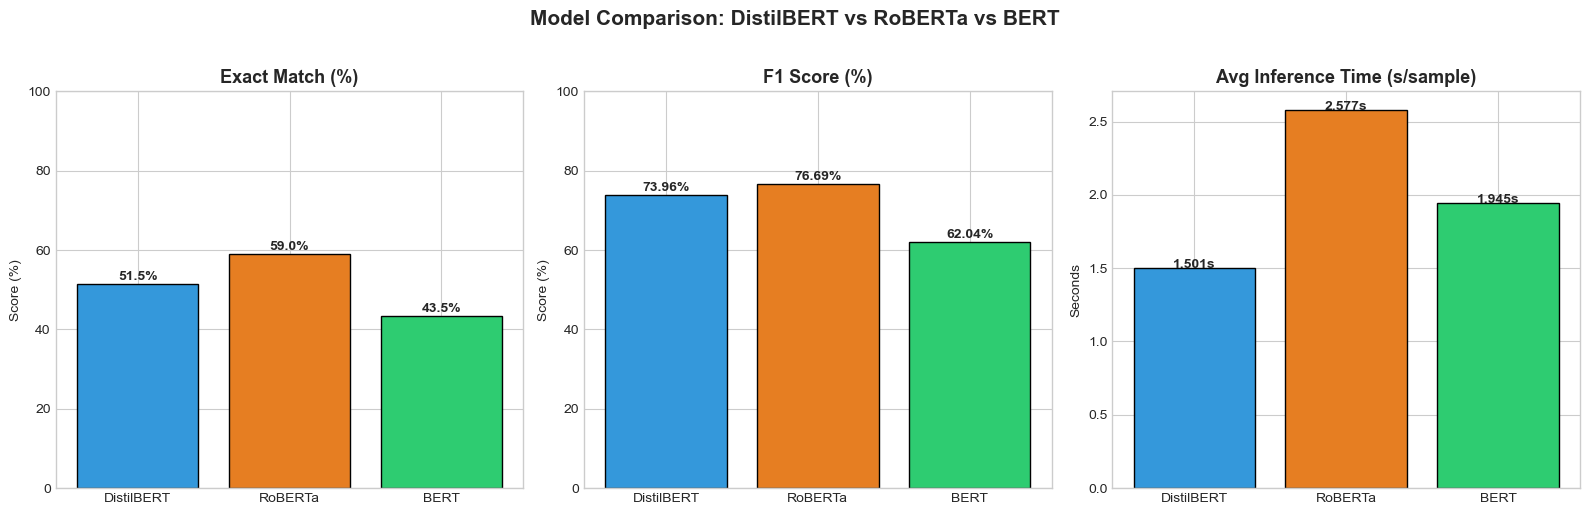

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = results_df['model'].tolist()
colors = ['#3498db', '#e67e22', '#2ecc71']
x = np.arange(len(model_names))

# EM Score
bars = axes[0].bar(model_names, results_df['EM'], color=colors, edgecolor='black')
axes[0].set_title('Exact Match (%)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Score (%)')
for bar, val in zip(bars, results_df['EM']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', fontweight='bold')

# F1 Score
bars = axes[1].bar(model_names, results_df['F1'], color=colors, edgecolor='black')
axes[1].set_title('F1 Score (%)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Score (%)')
for bar, val in zip(bars, results_df['F1']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', fontweight='bold')

# Avg Inference Time
bars = axes[2].bar(model_names, results_df['avg_time'], color=colors, edgecolor='black')
axes[2].set_title('Avg Inference Time (s/sample)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Seconds')
for bar, val in zip(bars, results_df['avg_time']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val}s', ha='center', fontweight='bold')

plt.suptitle('Model Comparison: DistilBERT vs RoBERTa vs BERT', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8: Deep Dive — Per-example Results

In [22]:
# Run best model on eval sample and show predictions vs ground truth
best_model_name = results_df.sort_values('F1', ascending=False).iloc[0]['model']

print(f'Best model: {best_model_name}\n')

rows = []
for _, row in eval_df.head(20).iterrows():
    result = answer_question(row['question'], row['context'], best_model_name)
    pred   = result['answer']
    truth  = row['answer_text']
    rows.append({
        'question'    : row['question'],
        'ground_truth': truth,
        'prediction'  : pred,
        'score'       : round(result['score'], 3),
        'EM'          : exact_match(pred, truth),
        'F1'          : round(f1_score_qa(pred, truth), 3)
    })

pred_df = pd.DataFrame(rows)
pred_df

Best model: RoBERTa



,question,ground_truth,prediction,score,EM,F1
0,What does increased oxygen concentrations in t...,carbon monoxide,carbon monoxide,0.817,1,1.000
1,Does the new deal include Video on demand and ...,no,Currently there is no indication,0.323,0,0.333
2,In which year did Genghis Khan's grandson inva...,1237,1237,0.964,1,1.000
3,Where is the Hyde Park Day School located?,the University of Chicago campus,University of Chicago campus,0.778,0,0.889
4,What does the WG I Summary for Policymakers re...,substantially increasing the atmospheric conce...,substantially increasing the atmospheric conc...,0.634,1,1.000
5,For how many years was evidence shown that hum...,"11,000 years","11,000",0.702,0,0.667
6,Who lost to the Broncos in the divisional round?,Pittsburgh Steelers,Pittsburgh Steelers,0.939,1,1.000
7,Who was hired to be the deputy director of the...,Joseph Shea,Joseph Shea,0.994,1,1.000
8,What register did Chris Keates think that some...,the sex offenders register,sex offenders register,0.753,0,0.857
9,What did Luther say would allow the Jews to stay?,that they convert,,0.636,0,0.000


In [25]:
# F1 score distribution for best model
all_f1 = []
for _, row in eval_df.iterrows():
    result = best_pipeline(question=row['question'], context=row['context'])
    all_f1.append(f1_score_qa(result['answer'], row['answer_text']))

plt.figure(figsize=(9, 4))
plt.hist(all_f1, bins=20, color='#3498db', edgecolor='black', alpha=0.85)
plt.axvline(np.mean(all_f1), color='red', linestyle='--',
            label=f'Mean F1: {np.mean(all_f1):.3f}')
plt.title(f'F1 Score Distribution — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('F1 Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('f1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'best_pipeline' is not defined

---
## Step 9 (BONUS): Interactive QA — Input Your Own Question

In [ ]:
def ask(context, question, model_name='DistilBERT'):
    """
    Ask any question given a context passage.
    Prints the answer from all loaded models.
    """
    print(f'📖 Context : {context[:200]}...' if len(context) > 200 else f'📖 Context : {context}')
    print(f'❓ Question: {question}\n')
    print('--- Answers ---')
    for name, qa in models.items():
        result = qa(question=question, context=context)
        print(f'  [{name:<10}]  "{result["answer"]}"  (confidence: {result["score"]:.3f})')


# --- Try your own! Change context and question below ---
my_context = """
The Amazon rainforest, also known as Amazonia, is a moist broadleaf tropical rainforest in
the Amazon biome that covers most of the Amazon basin of South America. This basin encompasses
7,000,000 km2, of which 5,500,000 km2 are covered by the rainforest. It represents over
half of the planet's remaining rainforests and comprises the largest and most biodiverse
tract of tropical rainforest in the world. Brazil holds around 60% of the Amazon rainforest.
"""

my_question = "Which country holds the most of the Amazon rainforest?"

ask(my_context, my_question)

---
## Step 10 (BONUS): Streamlit App

Save the cell below to `app.py` and run it with `streamlit run app.py`

In [ ]:
streamlit_app = '''
import streamlit as st
from transformers import pipeline

st.set_page_config(page_title="QA with Transformers", page_icon="🤖", layout="wide")
st.title("🤖 Question Answering with Transformers")
st.caption("Powered by DistilBERT, RoBERTa & BERT — fine-tuned on SQuAD v1.1")

@st.cache_resource
def load_models():
    return {
        "DistilBERT": pipeline("question-answering", model="distilbert-base-cased-distilled-squad"),
        "RoBERTa"   : pipeline("question-answering", model="deepset/roberta-base-squad2"),
        "BERT"      : pipeline("question-answering", model="deepset/bert-base-cased-squad2")
    }

models = load_models()

col1, col2 = st.columns([2, 1])

with col1:
    context = st.text_area("📖 Paste your context / passage here:", height=200,
                           placeholder="Enter a paragraph of text...")

with col2:
    question   = st.text_input("❓ Your question:", placeholder="What is...?")
    model_name = st.selectbox("🤖 Model:", list(models.keys()))
    run        = st.button("Get Answer", type="primary")

if run and context and question:
    with st.spinner("Thinking..."):
        result = models[model_name](question=question, context=context)

    st.success(f"**Answer:** {result['answer']}")
    st.metric("Confidence Score", f"{result['score']:.3f}")

    st.divider()
    st.subheader("Compare all models")
    for name, qa in models.items():
        r = qa(question=question, context=context)
        st.write(f"**{name}**: {r['answer']} _(score: {r['score']:.3f})_")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_app.strip())

print('✅ app.py saved!')
print('   Run it with: streamlit run app.py')

---
## Step 11: Summary

In [ ]:
best_row = results_df.sort_values('F1', ascending=False).iloc[0]

print('=' * 58)
print('   🤖 QUESTION ANSWERING WITH TRANSFORMERS — SUMMARY')
print('=' * 58)
print(f'Dataset        : SQuAD v1.1 (Stanford QA)')
print(f'Eval samples   : {EVAL_SAMPLE}')
print(f'Task type      : Span extraction (extractive QA)')
print()
print('--- Model Results ---')
for _, row in results_df.sort_values('F1', ascending=False).iterrows():
    flag = '🏆' if row['model'] == best_row['model'] else '  '
    print(f"{flag}  {row['model']:<12}  EM: {row['EM']:>5}%   F1: {row['F1']:>5}%   Speed: {row['avg_time']}s")
print()
print(f'Best Model     : {best_row["model"]}')
print(f'Best F1        : {best_row["F1"]}%')
print(f'Best EM        : {best_row["EM"]}%')
print('=' * 58)